In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,mean_squared_error,roc_auc_score,roc_curve
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import fbeta_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import matthews_corrcoef
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier

In [2]:
%matplotlib inline

In [3]:
data = pd.read_csv('./creditcard_2023.csv')

In [7]:
data.columns

Index(['id', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [9]:
data.head(3)

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64
 21  V21     56

In [13]:
data.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.638058e-17,-1.323544e-16,-3.518788e-17,-2.879008e-17,7.197521e-18,-3.838678e-17,-3.198898e-17,2.069287e-17,9.116859e-17,...,4.758361e-17,5.398140e-18,5.395017e-18,-1.999311e-18,-3.028957e-17,-7.547400e-18,-3.598760e-17,2.499139e-17,12041.957635,0.5
std,164149.486121,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222e+00,-9.952786e+00,-2.111111e+01,-4.351839e+00,-1.075634e+01,-3.751919e+00,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969e+00,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-6.560203e-01,-2.934955e-01,-4.458712e-01,-2.835329e-01,-1.922572e-01,-5.687446e-01,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-6.318948e-01,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-7.376152e-02,8.108788e-02,7.871758e-02,2.333659e-01,-1.145242e-01,9.252647e-02,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-1.189208e-02,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,7.070047e-01,4.397368e-01,4.977881e-01,5.259548e-01,4.729905e-02,5.592621e-01,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,6.728879e-01,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536e+00,4.271689e+01,2.616840e+01,2.178730e+02,5.958040e+00,2.027006e+01,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285e+00,1.132311e+02,7.725594e+01,24039.930000,1.0


In [21]:
# Check class distribution
print(data['Class'].value_counts(normalize=True))

Class
0    0.5
1    0.5
Name: proportion, dtype: float64


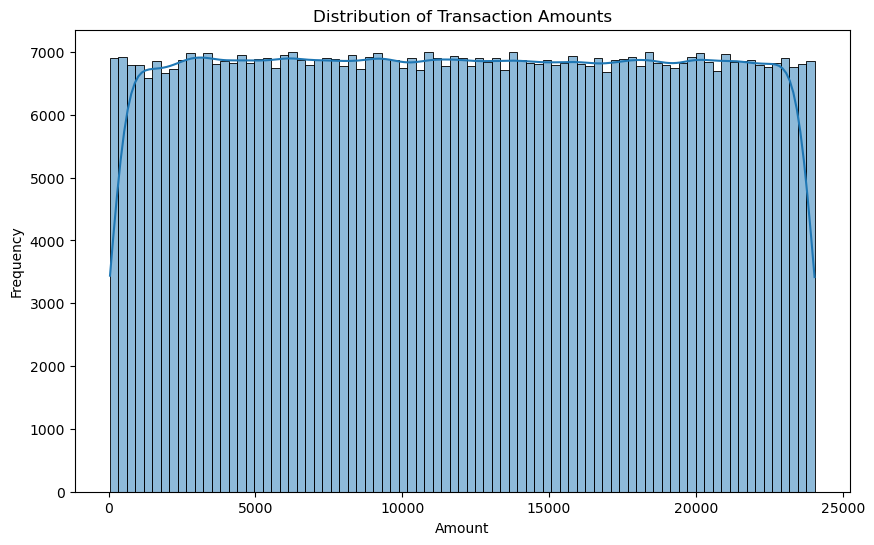

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt  # Assurez-vous aussi d'importer Matplotlib

# Visualize the distribution of transaction amounts
plt.figure(figsize=(10, 6))
sns.histplot(data['Amount'], kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

In [15]:
data.isna().sum()

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [17]:
data.isnull().sum()

id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [27]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = data.drop(['Class', 'id'], axis=1)
Y = data['Class']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame for better visualization
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Shape of scaled features:", X_scaled.shape)
print("\nFirst 5 rows of scaled features:")
print(X_scaled_df.head())

print("\nSummary statistics of scaled features:")
print(X_scaled_df.describe())

Shape of scaled features: (568630, 29)

First 5 rows of scaled features:
         V1        V2        V3        V4        V5        V6        V7  \
0 -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1  0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605  0.406466   
2 -0.260272 -0.949385  1.728538 -0.457986  0.074062  1.419481  0.743511   
3 -0.152152 -0.508959  1.746840 -1.090178  0.249486  1.143312  0.518269   
4 -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549  0.658849   

         V8        V9       V10  ...       V20       V21       V22       V23  \
0 -0.130006  0.727159  0.637735  ...  0.091202 -0.110552  0.217606 -0.134794   
1 -0.133118  0.347452  0.529808  ... -0.233984 -0.194936 -0.605761  0.079469   
2 -0.095576 -0.261297  0.690708  ...  0.361652 -0.005020  0.702906  0.945045   
3 -0.065130 -0.205698  0.575231  ... -0.378223 -0.146927 -0.038212 -0.214048   
4 -0.212660  1.049921  0.968046  ...  0.247237 -0.106984  0.729727 -0.161666

# Train test and split

In [12]:
# Min-max normalization
numeric_features = data.dtypes[data.dtypes != 'object'].index
data[numeric_features] = data[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max()-x.min()))
# Fill empty values by 0
data = data.fillna(0)

In [31]:
labelencoder = LabelEncoder()
data.iloc[:, -1] = labelencoder.fit_transform(data.iloc[:, -1])
#X = data.drop([' Label'], axis=1).values
#Y = data.iloc[:, -1].values.reshape(-1,1)
#Y = np.ravel(Y)
# Separate features and target
X = data.drop(['Class', 'id'], axis=1)
Y = data['Class']
Y = labelencoder.fit_transform(Y)  # Ensure consistent encoding
print("Encoded classes:", labelencoder.classes_)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = Y)

Encoded classes: [0 1]


In [33]:
X_train.shape

(454904, 29)

In [35]:
Y_test.shape

(113726,)

In [37]:
pd.Series(Y_train).value_counts()

0    227452
1    227452
Name: count, dtype: int64

Calculating the correlation matrix...
Correlation Matrix (preview):
          id        V1        V2        V3        V4        V5        V6  \
id  1.000000 -0.395741  0.424267 -0.663655  0.617554 -0.268445 -0.387916   
V1 -0.395741  1.000000 -0.561184  0.484499 -0.498963  0.517462  0.354728   
V2  0.424267 -0.561184  1.000000 -0.627810  0.579638 -0.631669 -0.341040   
V3 -0.663655  0.484499 -0.627810  1.000000 -0.687726  0.510351  0.508974   
V4  0.617554 -0.498963  0.579638 -0.687726  1.000000 -0.429243 -0.474403   

          V7        V8        V9  ...       V21       V22       V23       V24  \
id -0.414288  0.121282 -0.508427  ...  0.097948  0.036106  0.017594 -0.116685   
V1  0.573381 -0.226757  0.548973  ... -0.034669 -0.073729 -0.068917 -0.014651   
V2 -0.694022  0.191321 -0.585095  ... -0.013570  0.035346  0.151906 -0.027515   
V3  0.634336 -0.263018  0.648615  ... -0.021710 -0.041970 -0.058884  0.076460   
V4 -0.588648  0.199013 -0.676648  ... -0.013093  0.091197  0.043266 -0

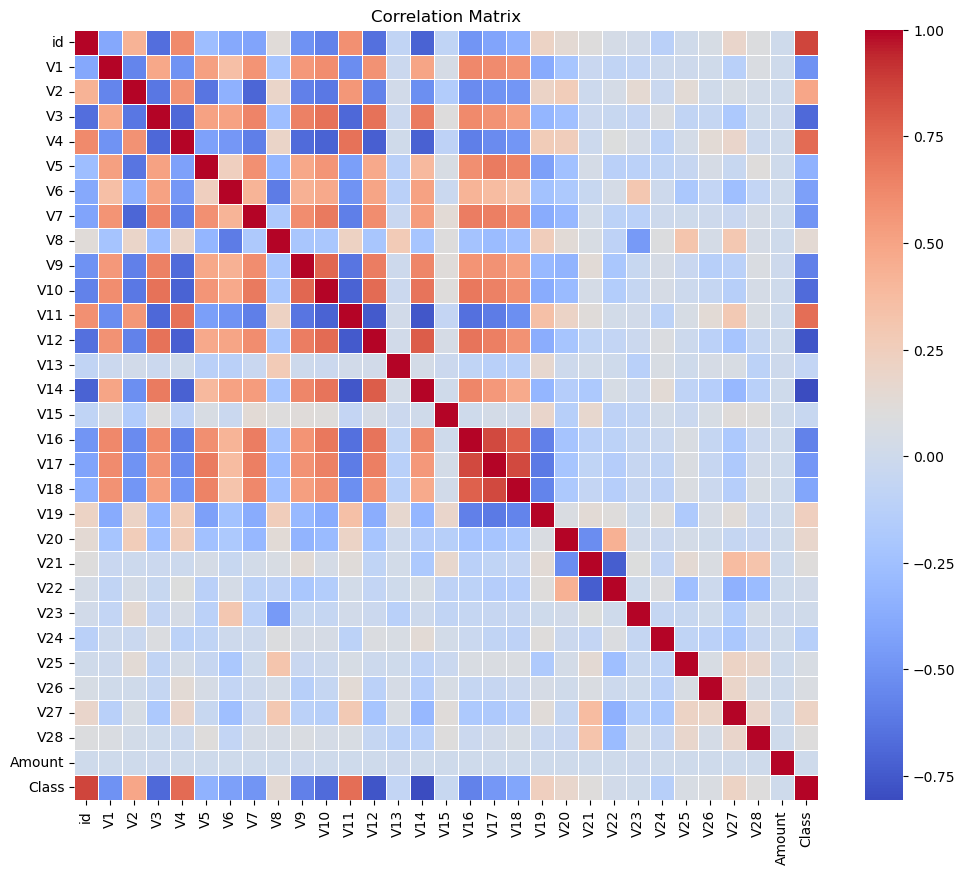

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
print("Calculating the correlation matrix...")
correlation_matrix = data.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# Visualize the correlation matrix with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Correlation with the target variable:
Class     1.000000
id        0.864283
V4        0.735981
V11       0.724278
V2        0.491878
V19       0.244081
V27       0.214002
V20       0.179851
V8        0.144294
V21       0.109640
V28       0.102024
V26       0.071052
V25       0.061847
V22       0.014098
V23       0.010255
Amount    0.002261
V15      -0.037948
V13      -0.071105
V24      -0.130107
V5       -0.338639
V18      -0.410091
V6       -0.435088
V17      -0.476377
V7       -0.491234
V1       -0.505761
V16      -0.573511
V9       -0.585522
V10      -0.673665
V3       -0.682095
V12      -0.768579
V14      -0.805669
Name: Class, dtype: float64


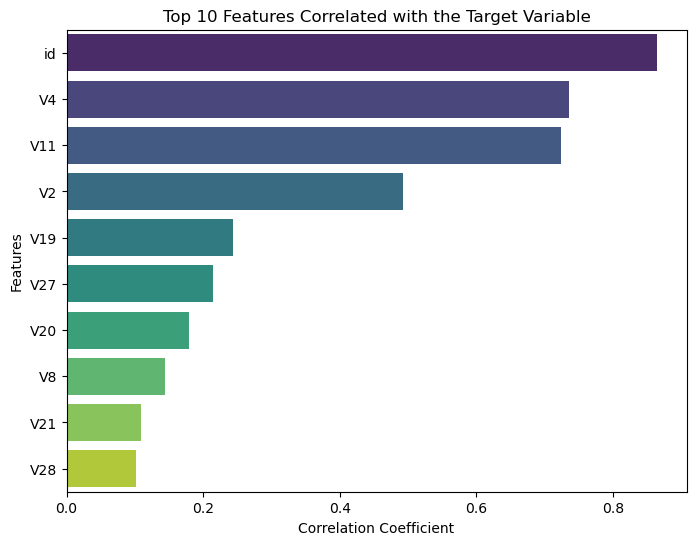

In [41]:
# Analyze correlation with the target variable ("Class")
if 'Class' in correlation_matrix.columns:
    target_corr = correlation_matrix['Class'].sort_values(ascending=False)
    print("Correlation with the target variable:")
    print(target_corr)

    # Visualize the strongest correlations with the target variable
    top_features = target_corr[1:11]  # Exclude correlation with itself
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
    plt.title('Top 10 Features Correlated with the Target Variable')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.show()
else:
    print("The 'Class' column does not exist in the dataset.")

In [43]:
# Check the range of correlation values
max_corr = correlation_matrix.where(~correlation_matrix.isna()).max().max()
min_corr = correlation_matrix.where(~correlation_matrix.isna()).min().min()

# Lower the threshold for moderate correlations
threshold = 0.8  # Adjust to a lower value
strong_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            strong_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print(f"Strongly correlated features (>|{threshold}|):")
for pair in strong_corr_pairs:
    print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

Strongly correlated features (>|0.8|):
V17 and V16 : 0.85
V18 and V17 : 0.85
Class and id : 0.86
Class and V14 : -0.81


In [45]:
#smote = SMOTE()
print(type(Y))
print(Y.dtype)
print(np.unique(Y))
pd.Series(Y_train).value_counts()

<class 'numpy.ndarray'>
int64
[0 1]


0    227452
1    227452
Name: count, dtype: int64

# Outliers removal

In [48]:
import pandas as pd
from scipy import stats

# Assuming X is a DataFrame and Y is a NumPy array
#Y_series = pd.Series(Y, index=X.index)  # Ensure Y has the same index as X

#z_scores = np.abs(stats.zscore(X))
#threshold = 3
#X_filtered = X[(z_scores < threshold).all(axis=1)]
#y_filtered = Y_series.loc[X_filtered.index]  # Now this will work

In [50]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import shapiro
from sklearn.ensemble import IsolationForest


def check_outliers(X, Y, threshold=3, iqr_factor=1.5):
    """
    Check if outliers exist in the dataset (X and Y) using Z-score or IQR.
    Returns True if outliers are detected in either X or Y, False otherwise.
    """
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    
    # Ensure Y is a pandas Series
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)
    
    # Filter only numeric columns for X
    X_numeric = X_normal.select_dtypes(include=['number'])
    
    # Calculate Z-scores for X and Y
    z_scores_X = np.abs(stats.zscore(X_numeric))
    z_scores_Y = np.abs(stats.zscore(Y_normal))
    
    outliers_zscore_X = (z_scores_X > threshold).any().any()
    outliers_zscore_Y = (z_scores_Y > threshold).any()
    
    # Calculate IQR for X and Y
    Q1_X = X_numeric.quantile(0.25)
    Q3_X = X_numeric.quantile(0.75)
    IQR_X = Q3_X - Q1_X
    
    Q1_Y = Y.quantile(0.25)
    Q3_Y = Y.quantile(0.75)
    IQR_Y = Q3_Y - Q1_Y
    
    outliers_iqr_X = ((X_numeric < (Q1_X - iqr_factor * IQR_X)) | (X_numeric > (Q3_X + iqr_factor * IQR_X))).any().any()
    outliers_iqr_Y = ((Y_normal < (Q1_Y - iqr_factor * IQR_Y)) | (Y_normal > (Q3_Y + iqr_factor * IQR_Y))).any()
    
    return outliers_zscore_X or outliers_zscore_Y or outliers_iqr_X or outliers_iqr_Y
    
def remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=1.5):
    """
    Removes outliers from normal transactions only.
    """

    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    X_fraud = X[Y == 1]
    Y_fraud = Y[Y == 1]

    # Outlier removal
    if method == "auto":
        print("Automatically selecting outlier removal method...")
        if X_normal.std().mean() < threshold:
            print("Using Z-score for outlier removal...")
            X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)
        else:
            print("Using IQR for outlier removal...")
            X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
            Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "zscore":
        print("Using Z-score for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)

    elif method == "iqr":
        print("Using IQR for outlier removal...")
        X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
        Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "isolation_forest":
        print("Using Isolation Forest for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_if(X_normal, Y_normal)

    # Reunify data
    X_cleaned = pd.concat([X_normal_cleaned, X_fraud], axis=0).sort_index()
    Y_cleaned = pd.concat([Y_normal_cleaned, Y_fraud], axis=0).sort_index()

    return X_cleaned, Y_cleaned

def remove_outliers_using_zscore(X, Y, threshold):
    """
    Removes outliers using the Z-score method.
    """
    z_scores = np.abs(stats.zscore(X))
    X_filtered = X[(z_scores < threshold).all(axis=1)]
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

def remove_outliers_using_iqr(X, iqr_factor=1.5):
    """
    Removes outliers using the IQR method.
    """
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    return X[~((X < (Q1 - iqr_factor * IQR)) | (X > (Q3 + iqr_factor * IQR))).any(axis=1)].copy()

def remove_outliers_using_if(X, Y, contamination=0.05):
    """
    Removes outliers using Isolation Forest.
    """
    model = IsolationForest(contamination=contamination, random_state=42)
    preds = model.fit_predict(X)
    X_filtered = X[preds != -1]  # IsolationForest marks outliers as -1
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

# Example usage:
# X_cleaned, Y_cleaned = remove_outliers(X, Y, method="auto")

In [52]:
# Assuming X is your DataFrame (features) and Y is your Series (target)
outliers_exist = check_outliers(X, Y)
print(f"Outliers detected: {outliers_exist}")

# Step 2: Remove outliers if they exist
if outliers_exist:
    X_filtered, y_filtered = remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=1.5)
    print("Outliers removed.")
else:
    print("No outliers detected. Data is clean.")

print("Cleaned Features (X):")
print(X_filtered)
print("\nCleaned Target (Y):")
print(y_filtered)

Outliers detected: True
Automatically selecting outlier removal method...
Using IQR for outlier removal...
Outliers removed.
Cleaned Features (X):
              V1        V2        V3        V4        V5        V6        V7  \
0      -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1       0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605  0.406466   
4      -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549  0.658849   
5       0.025302 -0.140514  1.191138 -0.707979  0.430490  0.458973  0.611050   
6       1.016482 -0.397181  0.497868 -0.144463  0.331022  0.629243  0.431262   
...          ...       ...       ...       ...       ...       ...       ...   
568625 -0.833437  0.061886 -0.899794  0.904227 -1.002401  0.481454 -0.370393   
568626 -0.670459 -0.202896 -0.068129 -0.267328 -0.133660  0.237148 -0.016935   
568627 -0.311997 -0.004095  0.137526 -0.035893 -0.042291  0.121098 -0.070958   
568628  0.636871 -0.516970 -0.300889 -0.144480  0.131

In [54]:
# Stratified split to maintain class balance
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y_filtered, test_size=0.2, random_state=42, stratify=y_filtered
)

print("Unique classes in y_train after split:", np.unique(y_train))
print("Class distribution in y_train after split:\n", pd.Series(y_train).value_counts())


Unique classes in y_train after split: [0 1]
Class distribution in y_train after split:
 1    227452
0    116022
Name: count, dtype: int64


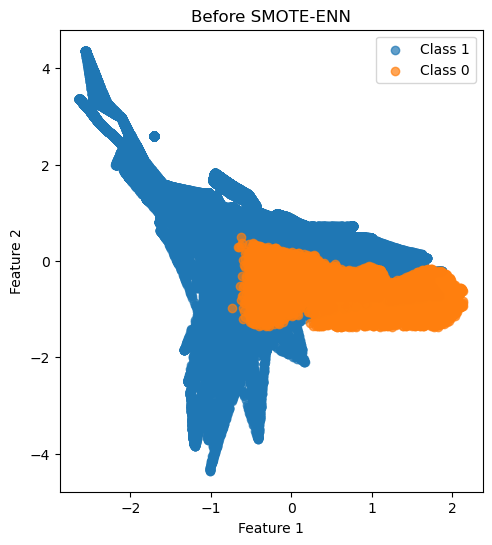

In [56]:
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN
from collections import Counter
import numpy as np
import pandas as pd

# -------------------------------
# For visualization, we use only two features.
# If X_train has more than two features, select the first two.
# -------------------------------

# Check if X_train is a DataFrame or a NumPy array and select two columns/features.
if isinstance(X_train, pd.DataFrame):
    if X_train.shape[1] > 2:
        X_vis = X_train.iloc[:, :2]
    else:
        X_vis = X_train.copy()
else:
    # Assuming X_train is a NumPy array
    if X_train.shape[1] > 2:
        X_vis = X_train[:, :2]
    else:
        X_vis = X_train.copy()

# -------------------------------
# Plot Original Data
# -------------------------------
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
# Get unique classes from y_train (works for both NumPy arrays and Series)
classes = np.unique(y_train) if isinstance(y_train, np.ndarray) else y_train.unique()

for cl in classes:
    # Build index mask for the current class
    if isinstance(X_vis, pd.DataFrame):
        idx = (y_train == cl)
        plt.scatter(X_vis.loc[idx, X_vis.columns[0]], 
                    X_vis.loc[idx, X_vis.columns[1]], 
                    label=f'Class {cl}', alpha=0.7)
    else:
        idx = (y_train == cl)
        plt.scatter(X_vis[idx, 0], X_vis[idx, 1], label=f'Class {cl}', alpha=0.7)

plt.title("Before SMOTE-ENN")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()


# SMOTE-ENN oversampling

In [59]:
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline

smote_enn = SMOTEENN(sampling_strategy=0.8, random_state=42)
#adasyn = ADASYN(sampling_strategy=0.8, random_state=42)
#rus = RandomUnderSampler(sampling_strategy=0.8, random_state=42)  # Reduce majority class

X_resampled, Y_resampled = smote_enn.fit_resample(X_train, y_train)
# Create a new DataFrame with the resampled data
data_resampled = pd.concat([pd.DataFrame(X_resampled), pd.Series(Y_resampled, name='Class')], axis=1)

# Display the class distribution after AdaSyn
class_distribution_after = Counter(data_resampled['Class'])
print("Class Distribution After SMOTE-ENN:", class_distribution_after)

Class Distribution After SMOTE-ENN: Counter({1: 197598, 0: 162323})


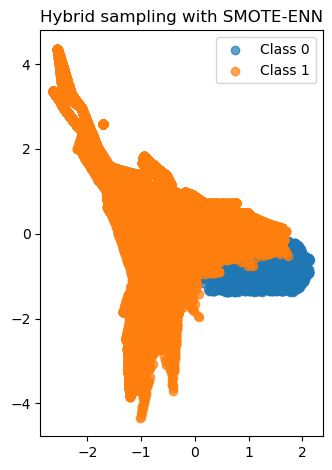

In [60]:
if isinstance(X_resampled, pd.DataFrame):
    if X_resampled.shape[1] > 2:
        X_res_vis = X_resampled.iloc[:, :2]
    else:
        X_res_vis = X_resampled.copy()
else:
    if X_resampled.shape[1] > 2:
        X_res_vis = X_resampled[:, :2]
    else:
        X_res_vis = X_resampled.copy()

# -------------------------------
# Plot Resampled Data
# -------------------------------
plt.subplot(1, 2, 2)
classes_res = np.unique(Y_resampled) if isinstance(Y_resampled, np.ndarray) else Y_resampled.unique()
for cl in classes_res:
    if isinstance(X_res_vis, pd.DataFrame):
        idx = (Y_resampled == cl)
        plt.scatter(X_res_vis.loc[idx, X_res_vis.columns[0]], 
                    X_res_vis.loc[idx, X_res_vis.columns[1]], 
                    label=f'Class {cl}', alpha=0.7)
    else:
        idx = (y_resampled == cl)
        plt.scatter(X_res_vis[idx, 0], X_res_vis[idx, 1], label=f'Class {cl}', alpha=0.7)

plt.title("Hybrid sampling with SMOTE-ENN")
plt.xlabel("")
plt.ylabel("")
plt.legend()

plt.tight_layout()
plt.show()

In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, Y_resampled, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = Y_resampled)

Calculating the correlation matrix...
Correlation Matrix (preview):
          V1        V2        V3        V4        V5        V6        V7  \
V1  1.000000 -0.743774  0.622758 -0.649166  0.661879  0.402560  0.762321   
V2 -0.743774  1.000000 -0.757010  0.720719 -0.709997 -0.408625 -0.839266   
V3  0.622758 -0.757010  1.000000 -0.810955  0.604422  0.562594  0.791970   
V4 -0.649166  0.720719 -0.810955  1.000000 -0.508017 -0.489656 -0.740968   
V5  0.661879 -0.709997  0.604422 -0.508017  1.000000  0.285420  0.796704   

          V8        V9       V10  ...       V21       V22       V23       V24  \
V1 -0.255260  0.725271  0.808402  ... -0.038508 -0.087401 -0.063776 -0.010468   
V2  0.208763 -0.729982 -0.794383  ... -0.032539  0.054385  0.234452 -0.002455   
V3 -0.277596  0.744696  0.839111  ... -0.012257 -0.091811 -0.073174  0.106574   
V4  0.216888 -0.791588 -0.844694  ... -0.032530  0.148579  0.049883 -0.097155   
V5 -0.359668  0.569717  0.664903  ...  0.054062 -0.162110 -0.143489 -0

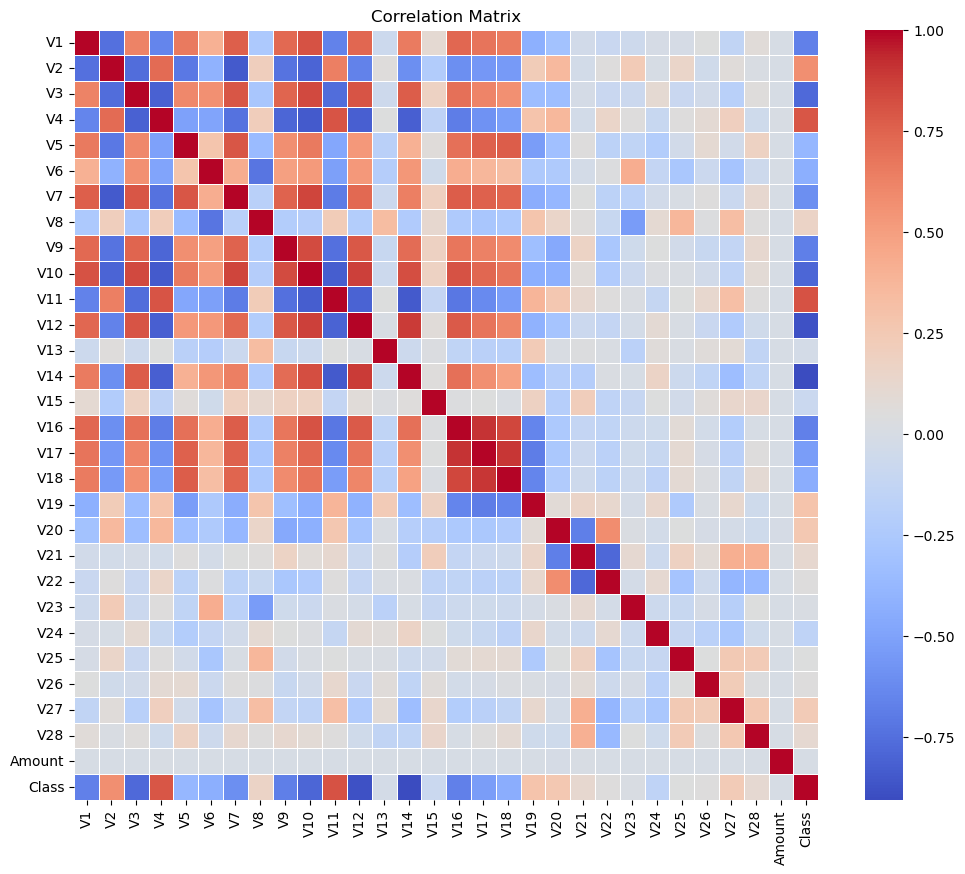

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
print("Calculating the correlation matrix...")
correlation_matrix = data_resampled.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# Visualize the correlation matrix with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Correlation with the target variable:
Class     1.000000
V11       0.811416
V4        0.792030
V2        0.572581
V19       0.287519
V20       0.257854
V27       0.239326
V8        0.161739
V21       0.117034
V28       0.108661
V22       0.051351
V26       0.050788
V25       0.044965
V23       0.013900
Amount    0.002836
V13      -0.026098
V15      -0.083789
V24      -0.147410
V5       -0.376787
V6       -0.432927
V18      -0.436912
V17      -0.528055
V7       -0.604169
V1       -0.667606
V16      -0.669815
V9       -0.679155
V3       -0.772599
V10      -0.792107
V12      -0.877771
V14      -0.904819
Name: Class, dtype: float64


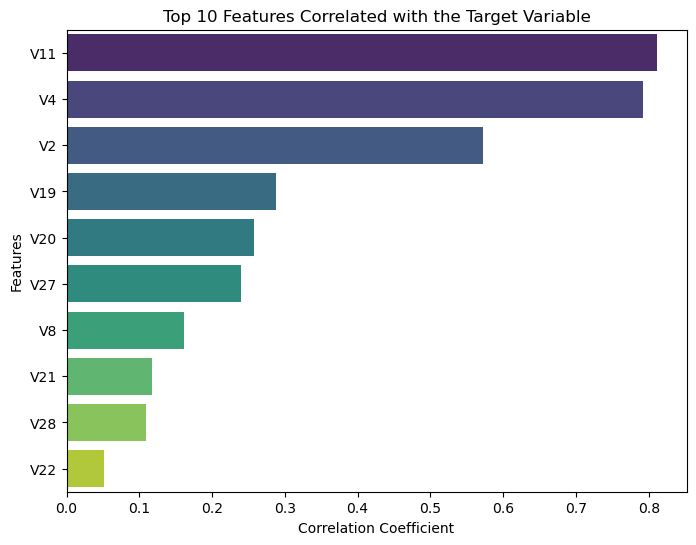

In [63]:
# Analyze correlation with the target variable ("Class")
if 'Class' in correlation_matrix.columns:
    target_corr = correlation_matrix['Class'].sort_values(ascending=False)
    print("Correlation with the target variable:")
    print(target_corr)

    # Visualize the strongest correlations with the target variable
    top_features = target_corr[1:11]  # Exclude correlation with itself
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
    plt.title('Top 10 Features Correlated with the Target Variable')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.show()
else:
    print("The 'Class' column does not exist in the dataset.")

In [64]:
# Check the range of correlation values
max_corr = correlation_matrix.where(~correlation_matrix.isna()).max().max()
min_corr = correlation_matrix.where(~correlation_matrix.isna()).min().min()

# Check for NaN values in the correlation matrix
#print("Number of NaN values in the correlation matrix:", correlation_matrix.isna().sum().sum())

# Lower the threshold for moderate correlations
threshold = 0.8  # Adjust to a lower value
strong_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            strong_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print(f"Strongly correlated features (>|{threshold}|):")
for pair in strong_corr_pairs:
    print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

Strongly correlated features (>|0.8|):
V4 and V3 : -0.81
V7 and V2 : -0.84
V10 and V1 : 0.81
V10 and V3 : 0.84
V10 and V4 : -0.84
V10 and V7 : 0.85
V10 and V9 : 0.83
V11 and V4 : 0.80
V11 and V10 : -0.82
V12 and V3 : 0.80
V12 and V4 : -0.82
V12 and V10 : 0.87
V12 and V11 : -0.81
V14 and V4 : -0.82
V14 and V10 : 0.83
V14 and V11 : -0.84
V14 and V12 : 0.89
V16 and V10 : 0.81
V17 and V16 : 0.91
V18 and V16 : 0.85
V18 and V17 : 0.90
Class and V11 : 0.81
Class and V12 : -0.88
Class and V14 : -0.90


# Feature importance

In [66]:
# Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50),
    #"CataBoost": CatBoostClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50, algorithm='SAMME')
}

In [67]:
feature_importances = np.zeros(X_resampled.shape[1])
for name, model in models.items():
    # Train the model
    model.fit(X_resampled,Y_resampled)
    if hasattr(model, "feature_importances_"):
        #feature_importances = model.feature_importances_
        feature_importances += model.feature_importances_
        print(f"{name} Feature Importances:\n{model.feature_importances_}")
    else:
        print(f"{name} does not have feature_importances_ attribute.")

Decision Tree Feature Importances:
[9.32232288e-05 8.12939517e-05 1.03113525e-03 5.41406002e-03
 1.24795015e-03 2.06170220e-04 3.08452687e-04 3.42369135e-04
 3.11324053e-04 1.04875585e-04 5.19974092e-03 5.03061816e-03
 4.64496131e-04 9.16894518e-01 1.82997161e-04 0.00000000e+00
 5.29812775e-02 1.55008995e-04 4.14411801e-04 6.87882858e-03
 1.45467144e-04 1.01214410e-04 3.96711526e-05 1.05778386e-04
 1.31144697e-04 2.76110651e-04 1.79758935e-03 5.46774153e-05
 5.59560867e-06]
Random Forest Feature Importances:
[7.64632295e-03 3.28939039e-02 5.77161197e-02 1.18017507e-01
 5.48638386e-03 1.45700184e-03 4.94145371e-02 1.45344008e-03
 6.50075642e-03 1.93169726e-01 1.13326293e-01 1.33639557e-01
 2.70383602e-04 1.42708756e-01 2.50859193e-04 3.95192000e-02
 6.01521168e-02 7.26101995e-03 1.31978131e-03 5.65123474e-03
 9.83798429e-03 2.25541835e-04 1.74768109e-03 4.79579110e-04
 3.02678068e-04 2.21617174e-04 7.68487943e-03 1.62021776e-03
 2.49209485e-05]
Extra Trees Feature Importances:
[3.338183

In [68]:
print(len(models))

5


In [69]:
avg_feature = feature_importances/len(models)

In [70]:
feature=(data_resampled.drop(['Class'],axis=1)).columns.values
print ("Features sorted by their score:")
sorted_features = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)
sorted_scores, sorted_names = zip(*sorted_features)
cumulative_importance = np.cumsum(sorted_scores)

index = np.where(cumulative_importance >= 0.9)[0][0]
important_features = sorted_names[:index+1]
# Ensure important_features contains the actual column names
important_features = list(important_features)

# Select only the columns corresponding to the important features
X_selected = X_resampled[important_features].values
print(important_features)
print(len(important_features))
print(X_resampled.columns)

Features sorted by their score:
['V14', 'V4', 'V12', 'V10', 'V11', 'V17', 'V3', 'V16', 'V1', 'V7']
10
Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21',
       'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')


In [71]:
len(sorted_features)

29

In [72]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, Y_resampled, train_size=0.8, test_size=0.2, random_state=42, stratify=Y_resampled)

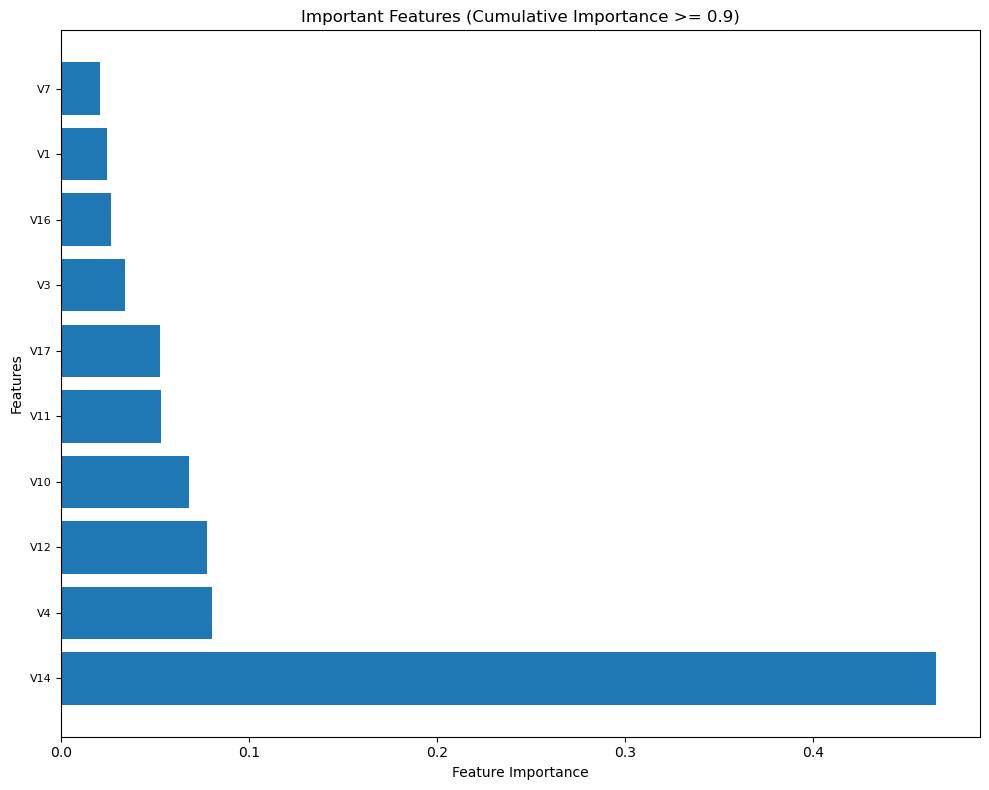

╒═══════════╤═══════════╕
│ Feature   │    Weight │
╞═══════════╪═══════════╡
│ V14       │ 0.515789  │
├───────────┼───────────┤
│ V4        │ 0.0891967 │
├───────────┼───────────┤
│ V12       │ 0.0860942 │
├───────────┼───────────┤
│ V10       │ 0.0751247 │
├───────────┼───────────┤
│ V11       │ 0.0587258 │
├───────────┼───────────┤
│ V17       │ 0.0581717 │
├───────────┼───────────┤
│ V3        │ 0.0377839 │
├───────────┼───────────┤
│ V16       │ 0.0295845 │
├───────────┼───────────┤
│ V1        │ 0.0268144 │
├───────────┼───────────┤
│ V7        │ 0.0227147 │
╘═══════════╧═══════════╛


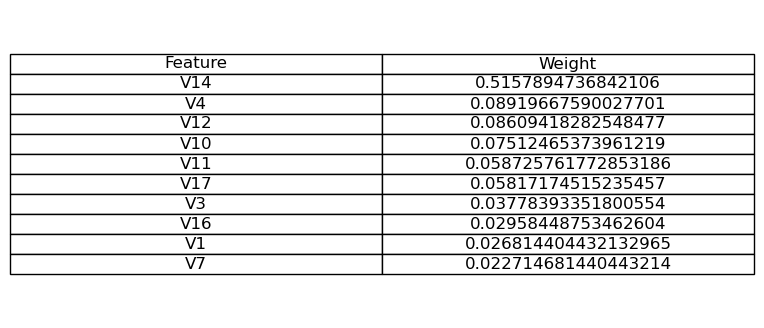

In [73]:
from tabulate import tabulate
# Step 10: Visualize the selected features
plt.figure(figsize=(10, 8))
plt.barh(range(len(important_features)), sorted_scores[:index+1], align='center')
plt.yticks(range(len(important_features)), important_features, fontsize=8)
plt.xlabel('Feature Importance', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.title('Important Features (Cumulative Importance >= 0.9)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 11: Display the selected features and their weights in a table
important_scores = sorted_scores[:index+1]
total_importance = np.sum(important_scores)
weights = important_scores / total_importance

table_data = [[feature, weight] for feature, weight in zip(important_features, weights)]
headers = ["Feature", "Weight"]

# Print the table
table_str = tabulate(table_data, headers, tablefmt="fancy_grid")
print(table_str)

# Save the table as a PDF
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
table = ax.table(cellText=table_data, colLabels=headers, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.savefig("feature_importance_table.pdf", bbox_inches="tight")

# GridSearch application

In [75]:
from sklearn.model_selection import GridSearchCV
# Define Parameter Grids for GridSearchCV
param_grid_dt = {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_et = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
param_grid_ada = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]}

In [76]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')
# Train and Tune Models
def grid_search(model, param_grid, name):
    grid = GridSearchCV(model, param_grid, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], refit='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best parameters for {name}: {grid.best_params_}")
    return grid.best_estimator_


best_dt = grid_search(DecisionTreeClassifier(criterion='entropy', random_state=42), param_grid_dt, "Decision Tree")
best_rf = grid_search(RandomForestClassifier(random_state=42), param_grid_rf, "Random Forest")
best_et = grid_search(ExtraTreesClassifier(random_state=42), param_grid_et, "Extra Trees")
best_xgb = grid_search(XGBClassifier(n_estimators=50, eval_metric='logloss'), param_grid_xgb, "XGBoost")
best_ada = grid_search(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50, algorithm='SAMME'), param_grid_ada, "AdaBoost")

Best parameters for Decision Tree: {'max_depth': 20, 'min_samples_split': 2}
Best parameters for Random Forest: {'max_depth': None, 'n_estimators': 200}
Best parameters for Extra Trees: {'max_depth': None, 'n_estimators': 200}
Best parameters for XGBoost: {'learning_rate': 0.2, 'n_estimators': 200}
Best parameters for AdaBoost: {'learning_rate': 1, 'n_estimators': 200}


# Voting for best results

In [78]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# Step 1: Store Predictions for Meta-Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_features_train = np.zeros((X_train.shape[0], 5))  # 5 models
meta_features_test = np.zeros((X_test.shape[0], 5))

# Base models
base_models = [
    ('dt', best_dt),
    ('rf', best_rf),
    ('et', best_et),
    ('xgb', best_xgb),
    ('ada', best_ada)
]
y_train = y_train.to_numpy()  # Convert to NumPy array

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    #y_tr, y_val = y_train[train_idx], y_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]


    
    # Train base models and store predictions for meta-model
    for i, (name, model) in enumerate(base_models):
        model.fit(X_tr, y_tr)
        meta_features_train[val_idx, i] = model.predict_proba(X_val)[:, 1]  # Use probabilities

# Fit final models on full training data to predict test meta-features
for i, (name, model) in enumerate(base_models):
    model.fit(X_train, y_train)
    meta_features_test[:, i] = model.predict_proba(X_test)[:, 1]

# Step 2: Define and Tune Voting Classifier with GridSearchCV
voting_clf = VotingClassifier(estimators=base_models, voting='soft')

# Tune Voting Weights Using GridSearchCV
param_grid_voting = {
    'weights': [
        (1, 1, 1, 1, 1),
        (1, 2, 2, 3, 1),
        (2, 1, 1, 1, 2),
        (3, 2, 1, 2, 1),
        (1, 1, 2, 2, 3)
    ]
}

grid_voting = GridSearchCV(voting_clf, param_grid_voting, cv=5, scoring='accuracy', n_jobs=-1)
grid_voting.fit(meta_features_train, y_train)  # Use meta-features for fitting

# Best Voting Classifier with Optimized Weights
best_voting = grid_voting.best_estimator_
print(f"Best Voting Weights: {grid_voting.best_params_}")


Best Voting Weights: {'weights': (1, 1, 2, 2, 3)}


In [79]:
print(f"best_voting : {best_voting }")

best_voting : VotingClassifier(estimators=[('dt',
                              DecisionTreeClassifier(criterion='entropy',
                                                     max_depth=20,
                                                     random_state=42)),
                             ('rf',
                              RandomForestClassifier(n_estimators=200,
                                                     random_state=42)),
                             ('et',
                              ExtraTreesClassifier(n_estimators=200,
                                                   random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsa...
                       

# Second Stage : LSTM predictions

In [81]:
from tensorflow.keras.optimizers import Adam
# Step 3: LSTM Meta-Learner on top of Voting Classifier Predictions
best_voting.fit(X_train, y_train)

# Get Predictions from Voting Classifier (probabilities)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities of class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities of class 1

# Reshape for LSTM (required shape: [samples, time_steps, features])
X_train_lstm = y_pred_voting_train.reshape(-1, 1, 1)  # Shape (samples, 1, 1)
X_test_lstm = y_pred_voting_test.reshape(-1, 1, 1)  # Shape (samples, 1, 1)

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Check the shape of the labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)

lstm_model = Sequential([
    LSTM(64, return_sequences=False),  # Set return_sequences to False
    Dropout(0.2),
    Dense(2, activation='softmax')  # Two neurons for two classes
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the LSTM Meta-Learner
lstm_model.fit(X_train_lstm, y_train_cat, epochs=20, batch_size=16, validation_data=(X_test_lstm, y_test_cat))


# Step 4: Evaluate LSTM Meta-Learner
y_pred_lstm = lstm_model.predict(X_test_lstm)
y_pred_lstm_labels = np.argmax(y_pred_lstm, axis=1)

# Calculate accuracy of LSTM Meta-Learner
final_accuracy = accuracy_score(y_test, y_pred_lstm_labels)
print("Final LSTM Meta-Learner Accuracy:", final_accuracy)

Shape of y_train_cat: (287936, 2)
Shape of y_test_cat: (71985, 2)
Epoch 1/20
17996/17996 ━━━━━━━━━━━━━━━━━━━━ 10s 503us/step - accuracy: 0.9830 - loss: 0.0392 - val_accuracy: 0.9997 - val_loss: 0.0032
Epoch 2/20
17996/17996 ━━━━━━━━━━━━━━━━━━━━ 9s 495us/step - accuracy: 1.0000 - loss: 1.0316e-08 - val_accuracy: 0.9997 - val_loss: 0.0037
Epoch 3/20
17996/17996 ━━━━━━━━━━━━━━━━━━━━ 9s 493us/step - accuracy: 1.0000 - loss: 3.3902e-10 - val_accuracy: 0.9997 - val_loss: 0.0037
Epoch 4/20
17996/17996 ━━━━━━━━━━━━━━━━━━━━ 9s 496us/step - accuracy: 1.0000 - loss: 9.7843e-11 - val_accuracy: 0.9997 - val_loss: 0.0040
Epoch 5/20
17996/17996 ━━━━━━━━━━━━━━━━━━━━ 9s 494us/step - accuracy: 1.0000 - loss: 8.0362e-11 - val_accuracy: 0.9997 - val_loss: 0.0039
Epoch 6/20
17996/17996 ━━━━━━━━━━━━━━━━━━━━ 9s 494us/step - accuracy: 1.0000 - loss: 9.0507e-11 - val_accuracy: 0.9997 - val_loss: 0.0039
Epoch 7/20
17996/17996 ━━━━━━━━━━━━━━━━━━━━ 9s 493us/step - accuracy: 1.0000 - loss: 4.0630e-11 - val_accurac

# Final performance results

In [83]:
# Store results
results = []

# Now evaluate the metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, cohen_kappa_score, matthews_corrcoef, roc_auc_score
y_proba_lstm = y_pred_lstm[:, 1]  # Extract probability of class 1
# Check the shape of y_pred_lstm
#print("Shape of y_pred_lstm:", y_pred_lstm.shape)
metrics_lstm = [
    "LSTM",
    accuracy_score(y_test, y_pred_lstm_labels),
    precision_score(y_test, y_pred_lstm_labels),
    recall_score(y_test, y_pred_lstm_labels),
    f1_score(y_test, y_pred_lstm_labels),
    fbeta_score(y_test, y_pred_lstm_labels, beta=2),
    cohen_kappa_score(y_test, y_pred_lstm_labels),
    matthews_corrcoef(y_test, y_pred_lstm_labels),
    roc_auc_score(y_test, y_proba_lstm)  # Use probabilities for ROC AUC
]
#print(metrics_lstm)
results.append(metrics_lstm)

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32465
           1       1.00      1.00      1.00     39520

    accuracy                           1.00     71985
   macro avg       1.00      1.00      1.00     71985
weighted avg       1.00      1.00      1.00     71985

Confusion matrix:
[[32464     1]
 [   22 39498]]
Accuracy: 0.999680488990762
Pricision: 0.9999746829033647
Recall: 0.9994433198380567
ROC AUC Score: 0.9999723308377568
F1-Score: 0.9997089307634872
F2-Score: 0.9995495472696997
Cohen's Kappa Score: 0.9993548177182796
Matthews Correlation Coefficient (MCC): 0.9993549911136946


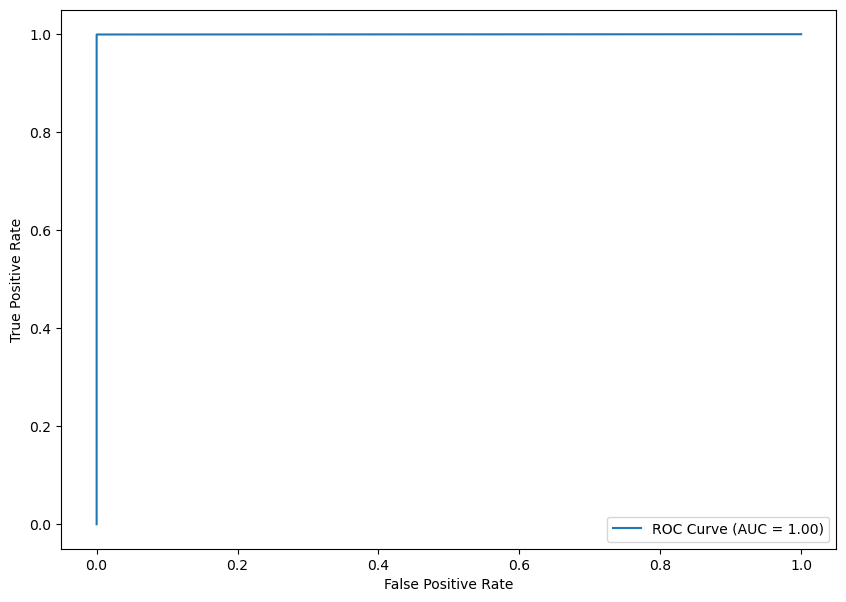

In [84]:
print("Classification report:")
print(classification_report(y_test, y_pred_lstm_labels))
print("Confusion matrix:")

print(confusion_matrix(y_test, y_pred_lstm_labels))
print("Accuracy:", accuracy_score(y_test, y_pred_lstm_labels))
print("Pricision:", precision_score(y_test, y_pred_lstm_labels))
print("Recall:",recall_score(y_test, y_pred_lstm_labels))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_lstm))
print("F1-Score:", f1_score(y_test, y_pred_lstm_labels))
# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_labels, beta=2)
print("F2-Score:", f2)
print("Cohen's Kappa Score:", cohen_kappa_score(y_test, y_pred_lstm_labels))
print("Matthews Correlation Coefficient (MCC):", matthews_corrcoef(y_test, y_pred_lstm_labels))
# Calculer l'AUC
auc_score = roc_auc_score(y_test, y_proba_lstm)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Add autoencoders

In [86]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

# Define the Autoencoder
input_shape = (X_train_lstm.shape[1],)  # Adjust input shape based on your data
input_layer = Input(shape=input_shape)

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(128, activation='relu')(encoded)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(input_shape[0], activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train the Autoencoder
autoencoder.fit(X_train_lstm, X_train_lstm,
                epochs=50,
                batch_size=32,
                validation_data=(X_test_lstm, X_test_lstm))

# Print model summary
autoencoder.summary()

# Step 3: Create an Encoder Model for Feature Extraction
encoder = Model(input_layer, encoded)

# Step 4: LSTM Meta-Learner on top of the encoded features
# (Assuming best_voting is a previously trained ensemble model)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities for class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Get the encoded representations (compressed features) for both train and test data
X_train_encoded = encoder.predict(X_train_lstm)
X_test_encoded = encoder.predict(X_test_lstm)

# Check the shape of the categorical labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)


Epoch 1/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 10s 1ms/step - loss: 0.0047 - val_loss: 2.2794e-04
Epoch 2/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0012 - val_loss: 3.6161e-04
Epoch 3/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 9.2527e-04 - val_loss: 2.8926e-04
Epoch 4/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 8.5855e-04 - val_loss: 3.5582e-04
Epoch 5/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 7.9970e-04 - val_loss: 2.0893e-04
Epoch 6/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 7.5344e-04 - val_loss: 4.4477e-04
Epoch 7/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 7.3289e-04 - val_loss: 4.1730e-04
Epoch 8/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 6.9298e-04 - val_loss: 1.8598e-04
Epoch 9/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 6.9432e-04 - val_loss: 1.9387e-04
Epoch 10/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 6.6896e-04 - val_loss: 3.1146e-04
Epoch 11/50
8998/8998 ━━━━━━━━━━━━━━━━━━━━ 9s 

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,941 (999.77 KB)

 Trainable params: 84,801 (331.25 KB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 169,604 (662.52 KB)

8998/8998 ━━━━━━━━━━━━━━━━━━━━ 2s 228us/step
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 1s 243us/step
Shape of y_train_cat: (287936, 2)
Shape of y_test_cat: (71985, 2)


In [87]:
X_train_encoded = X_train_encoded[:y_train_cat.shape[0]]
X_test_encoded = X_test_encoded[:y_test_cat.shape[0]]
#print("X_train_encoded shape:", X_train_encoded.shape)
#print("y_train_cat shape:", y_train_cat.shape)
#print("X_test_encoded shape:", X_test_encoded.shape
# Ensure the shape is (samples, time_steps, features) for LSTM
X_train_lstm_ae = X_train_encoded.reshape(X_train_encoded.shape[0], 1, -1)
X_test_lstm_ae = X_test_encoded.reshape(X_test_encoded.shape[0], 1, -1)


In [88]:
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Recall
lstm_model = Sequential([
    #Input(shape=(X_train_lstm_ae.shape[1], X_train_lstm_ae.shape[2])),
    # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.3),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Now fit the LSTM Meta-Learner on the reshaped encoded data
history = lstm_model.fit(X_train_lstm_ae, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm_ae, y_test_cat))

Epoch 1/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 12s 682us/step - accuracy: 0.9986 - loss: 0.0093 - recall: 0.9986 - val_accuracy: 0.9996 - val_loss: 0.0038 - val_recall: 0.9996
Epoch 2/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 11s 673us/step - accuracy: 1.0000 - loss: 4.1539e-04 - recall: 1.0000 - val_accuracy: 0.9995 - val_loss: 0.0079 - val_recall: 0.9995
Epoch 3/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 11s 675us/step - accuracy: 1.0000 - loss: 3.9714e-04 - recall: 1.0000 - val_accuracy: 0.9996 - val_loss: 0.0035 - val_recall: 0.9996
Epoch 4/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 12s 684us/step - accuracy: 1.0000 - loss: 1.9361e-04 - recall: 1.0000 - val_accuracy: 0.9995 - val_loss: 0.0072 - val_recall: 0.9995
Epoch 5/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 11s 676us/step - accuracy: 1.0000 - loss: 5.9636e-04 - recall: 1.0000 - val_accuracy: 0.9996 - val_loss: 0.0034 - val_recall: 0.9996
Epoch 6/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 11s 678us/step - accuracy: 1.0000 - loss: 3.4376e-04 - recall: 1.0000 - val

In [89]:
# LSTM without Autoencoder Model
lstm_model_raw = Sequential([
    #Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    
   # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.3),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model_raw.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Train the LSTM Meta-Learner
history_raw = lstm_model_raw.fit(X_train_lstm, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm, y_test_cat))#, callbacks=[early_stop], verbose=1)


Epoch 1/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 12s 631us/step - accuracy: 0.9935 - loss: 0.0197 - recall_1: 0.9935 - val_accuracy: 0.9996 - val_loss: 0.0033 - val_recall_1: 0.9996
Epoch 2/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 11s 622us/step - accuracy: 1.0000 - loss: 7.2400e-04 - recall_1: 1.0000 - val_accuracy: 0.9997 - val_loss: 0.0028 - val_recall_1: 0.9997
Epoch 3/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 11s 668us/step - accuracy: 1.0000 - loss: 4.7031e-04 - recall_1: 1.0000 - val_accuracy: 0.9997 - val_loss: 0.0030 - val_recall_1: 0.9997
Epoch 4/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 11s 649us/step - accuracy: 1.0000 - loss: 3.5979e-04 - recall_1: 1.0000 - val_accuracy: 0.9997 - val_loss: 0.0029 - val_recall_1: 0.9997
Epoch 5/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 11s 650us/step - accuracy: 1.0000 - loss: 3.5368e-04 - recall_1: 1.0000 - val_accuracy: 0.9996 - val_loss: 0.0076 - val_recall_1: 0.9996
Epoch 6/30
16938/16938 ━━━━━━━━━━━━━━━━━━━━ 11s 627us/step - accuracy: 1.0000 - loss: 3.4155e-04 - 

In [90]:
# Step 5: Evaluate LSTM Meta-Learner
y_pred_lstm_ae = lstm_model.predict(X_test_lstm_ae)
y_pred_lstm_ae_labels = np.argmax(y_pred_lstm_ae, axis=1)
y_pred_lstm_raw = lstm_model_raw.predict(X_test_lstm)
accuracy_raw = accuracy_score(y_test, np.argmax(y_pred_lstm_raw, axis=1))

# Calculate accuracy of LSTM Meta-Learner
final_accuracy = accuracy_score(y_test, y_pred_lstm_ae_labels)
#print("Final LSTM Meta-Learner Accuracy:", final_accuracy)

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 1s 286us/step
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 1s 263us/step


In [91]:
print("Accuracy without Autoencoder:", accuracy_raw)
print("Accuracy with Autoencoder:", final_accuracy)

Accuracy without Autoencoder: 0.999680488990762
Accuracy with Autoencoder: 0.9994721122456067


Performance without Autoencoder :
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32465
           1       1.00      1.00      1.00     39520

    accuracy                           1.00     71985
   macro avg       1.00      1.00      1.00     71985
weighted avg       1.00      1.00      1.00     71985

Accuracy: 0.999680488990762
Precision : 0.9999746829033647
Recall : 0.9994433198380567
F1-Score : 0.9997089307634872
F2-Score : 0.9995495472696997
Cohen's Kappa Score : 0.9993548177182796
Matthews Correlation Coefficient (MCC) : 0.9993549911136946
Specificity : 0.9999691975974127
G-means : 0.9997062241391497


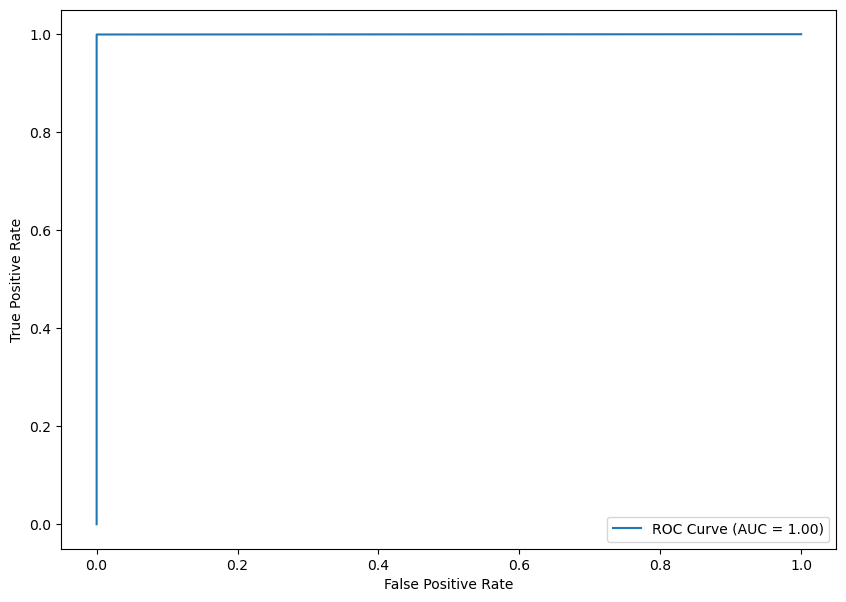

In [92]:
print("Performance without Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_labels))
#print("Confusion matrix:")
cm1 = confusion_matrix(y_test, y_pred_lstm_labels)

print("Accuracy:", accuracy_score(y_test, y_pred_lstm_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Confusion matrix Without autoencoder:


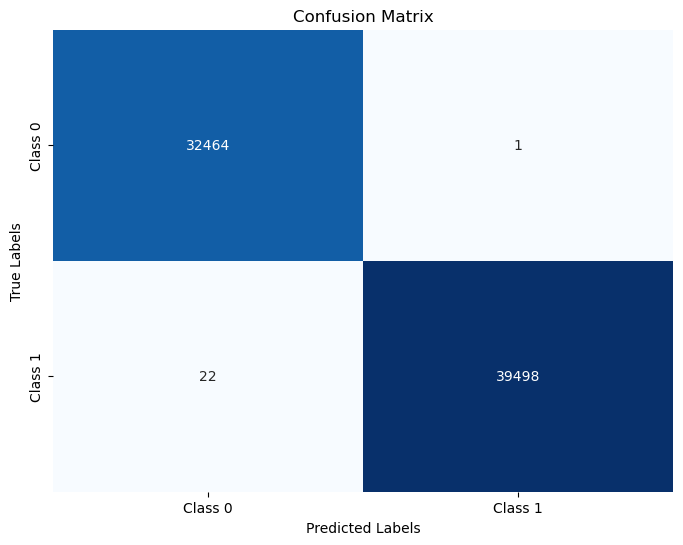

In [93]:
print("Confusion matrix Without autoencoder:")
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Performance with Autoencoder :
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     32465
           1       1.00      1.00      1.00     39520

    accuracy                           1.00     71985
   macro avg       1.00      1.00      1.00     71985
weighted avg       1.00      1.00      1.00     71985

Accuracy: 0.9994721122456067
Precision : 1.0
Recall : 0.9990384615384615
F1-Score : 0.9995189995189995
F2-Score : 0.9992306212733217
Cohen's Kappa Score : 0.998934096481852
Matthews Correlation Coefficient (MCC) : 0.9989346639519773
Specificity : 1.0
G-means : 0.9995191151441084


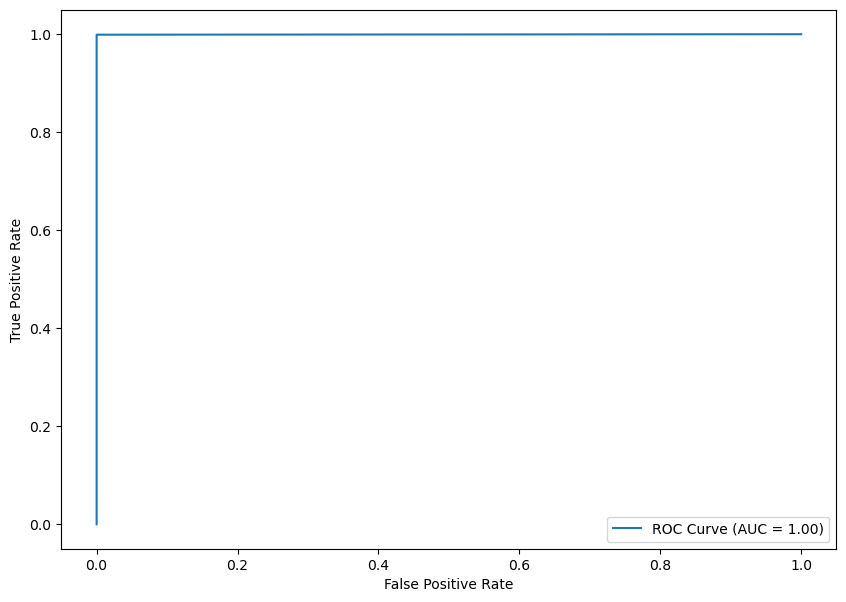

In [94]:
print("Performance with Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_ae_labels))
cm = confusion_matrix(y_test, y_pred_lstm_ae_labels)
#print(confusion_matrix(y_test, y_pred_lstm_ae_labels))
print("Accuracy:", accuracy_score(y_test, y_pred_lstm_ae_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_ae_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_ae_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_ae_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_ae_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_ae_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_ae_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_ae_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_ae_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_ae_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Confusion matrix With autoencoder:


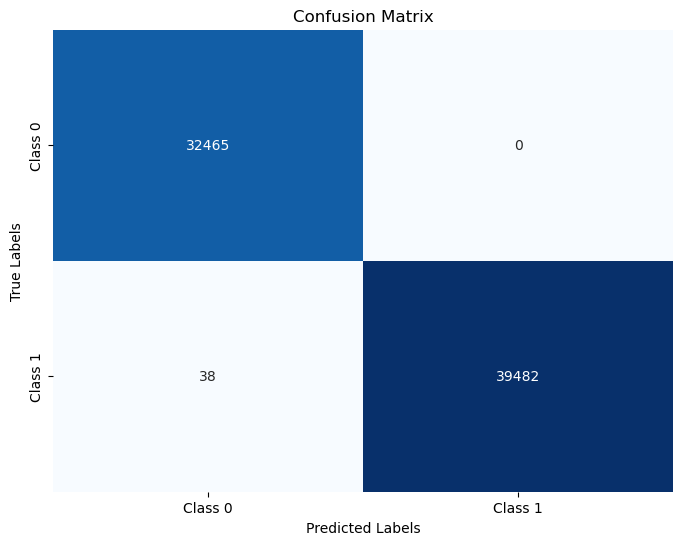

In [95]:
print("Confusion matrix With autoencoder:")
# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, 
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])

plt.title("Confusion Matrix")
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [96]:
import pickle
from tensorflow.keras.models import load_model

# Sauvegarde du modèle avec pickle
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(lstm_model, f)

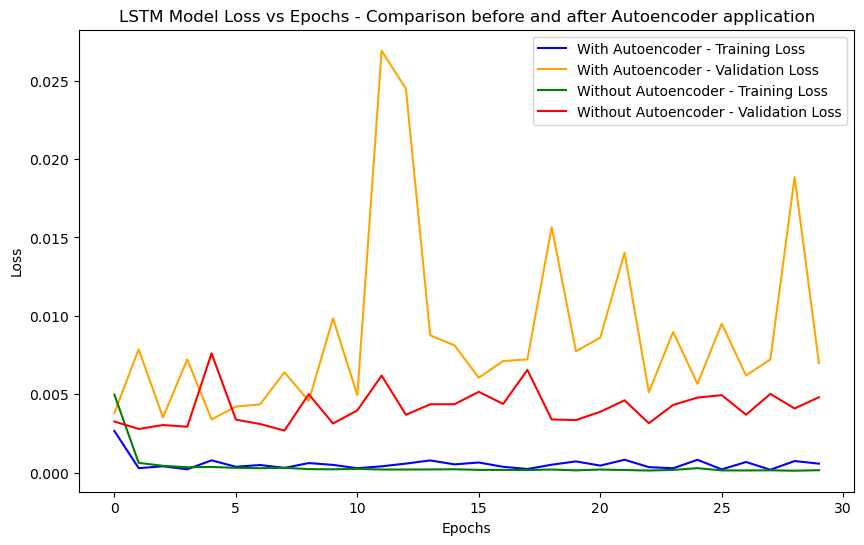

In [97]:
# Extract loss values
train_loss = history.history['loss']  # Training loss for each epoch
val_loss = history.history['val_loss']  # Validation loss for each epoch (if validation data is provided)

train_loss2 = history_raw.history['loss']
val_loss2 = history_raw.history['val_loss']

# Plotting the loss curves for both models
plt.figure(figsize=(10, 6))

# Plot for Model 1
plt.plot(train_loss, label='With Autoencoder - Training Loss', color='blue')
plt.plot(val_loss, label='With Autoencoder - Validation Loss', color='orange')

# Plot for Model 2
plt.plot(train_loss2, label='Without Autoencoder - Training Loss', color='green')
plt.plot(val_loss2, label='Without Autoencoder - Validation Loss', color='red')

# Adding labels and title
plt.title('LSTM Model Loss vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

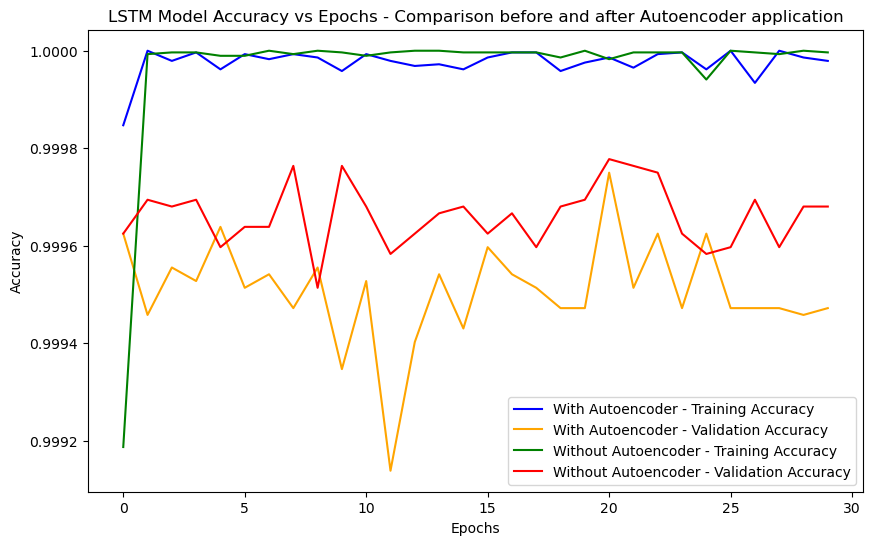

In [98]:
train_acc1 = history.history['accuracy']
val_acc1 = history.history['val_accuracy']

train_acc2 = history_raw.history['accuracy']
val_acc2 = history_raw.history['val_accuracy']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_acc1, label='With Autoencoder - Training Accuracy', color='blue')
plt.plot(val_acc1, label='With Autoencoder - Validation Accuracy', color='orange')

plt.plot(train_acc2, label='Without Autoencoder - Training Accuracy', color='green')
plt.plot(val_acc2, label='Without Autoencoder - Validation Accuracy', color='red')


plt.title('LSTM Model Accuracy vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

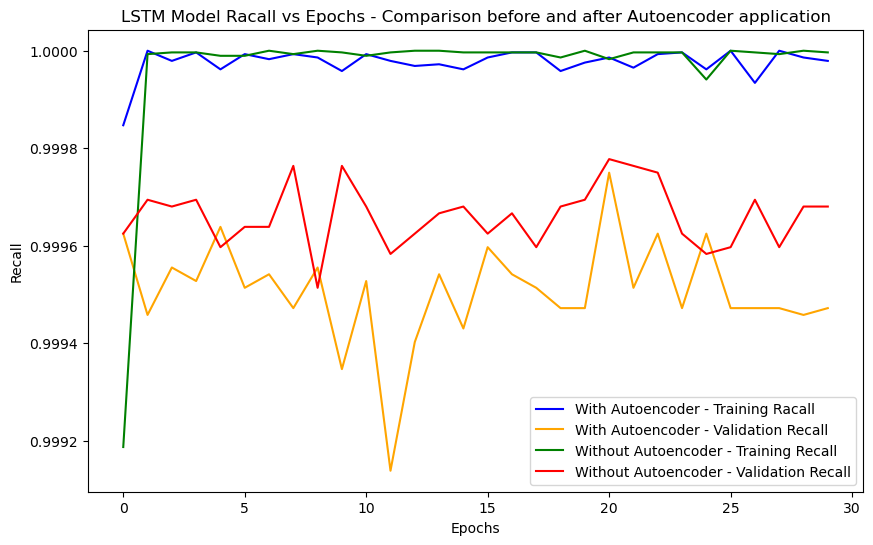

In [99]:
train_recall1 = history.history['recall']
val_recall1 = history.history['val_recall']

train_recall2 = history_raw.history['recall_1']
val_recall2 = history_raw.history['val_recall_1']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_recall1, label='With Autoencoder - Training Racall', color='blue')
plt.plot(val_recall1, label='With Autoencoder - Validation Recall', color='orange')

plt.plot(train_recall2, label='Without Autoencoder - Training Recall', color='green')
plt.plot(val_recall2, label='Without Autoencoder - Validation Recall', color='red')


plt.title('LSTM Model Racall vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()
plt.show()